# An Analysis of the Factors Influencing Track Popularity on Spotify

**Course project — Probability & Mathematical Statistics, National Economics University (NEU)**
Group members: Vu Quang Huy, Tran Hoang Phu

This notebook explores what actually drives a track's popularity on Spotify: descriptive statistics, correlation analysis, a multiple linear regression model, and two hypothesis tests (explicit vs. non-explicit tracks, and popularity across genres).

**Dataset:** [Spotify Tracks Dataset](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) — 114,000 tracks across 114 genres, with audio features pulled from the Spotify API.

## Objectives

- Describe the general characteristics of tracks using their audio features
- Examine the relationship between audio features and popularity
- Test whether explicit content or genre create significant differences in popularity
- Build a regression model to predict popularity from audio features

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 1. Load & Inspect the Data

In [2]:
# Locate the dataset inside the Kaggle input directory
data_path = None
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.lower().endswith(".csv"):
            data_path = os.path.join(root, f)
            break
    if data_path:
        break

assert data_path is not None, "Attach the 'Spotify Tracks Dataset' to this notebook first (Add Input, top right)."

df = pd.read_csv(data_path, index_col=0)
print(f"Loaded {df.shape[0]:,} tracks, {df.shape[1]} columns")
df.head()

Loaded 114,000 tracks, 20 columns


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 

## 2. Descriptive Statistics

In [4]:
key_vars = ["popularity", "danceability", "energy", "loudness", "valence", "tempo"]
desc = df[key_vars].describe().T
desc

,count,mean,std,min,25%,50%,75%,max
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000,50.000,100.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580,0.695,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685,0.854,1.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004,-5.003,4.532
valence,114000.0,0.474068,0.259261,0.000,0.26000,0.464,0.683,0.995
tempo,114000.0,122.147837,29.978197,0.000,99.21875,122.017,140.071,243.372


**Reading the table:**
- Popularity averages ~33/100 with a large spread (std ≈ 22) — most tracks never reach mainstream popularity, and only a few break into "hit" territory (score > 80).
- Energy (mean 0.64) and danceability (mean 0.57) both skew toward vibrant, rhythmic tracks — consistent with current mainstream production trends.
- Average loudness (-8.26 dB) and tempo (~122 BPM) sit right in typical Pop/Dance/House mastering ranges.

### Figure 1 — Distribution of Popularity

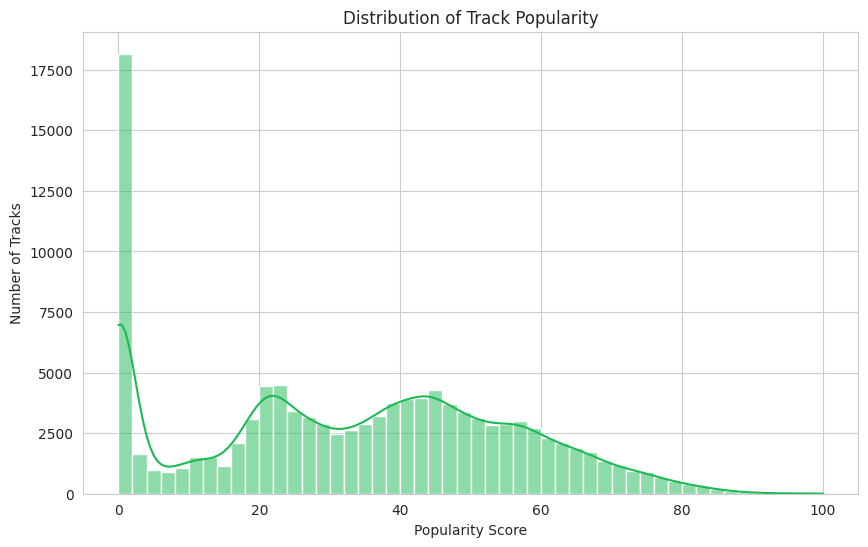

In [5]:
plt.figure()
sns.histplot(df["popularity"], bins=50, kde=True, color="#1DB954")
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity Score")
plt.ylabel("Number of Tracks")
plt.show()

The distribution is right-skewed: most tracks cluster at low popularity, with secondary bumps around the 20/40/50 marks and a long tail stretching toward 100.

### Figure 2 — Popularity Boxplot

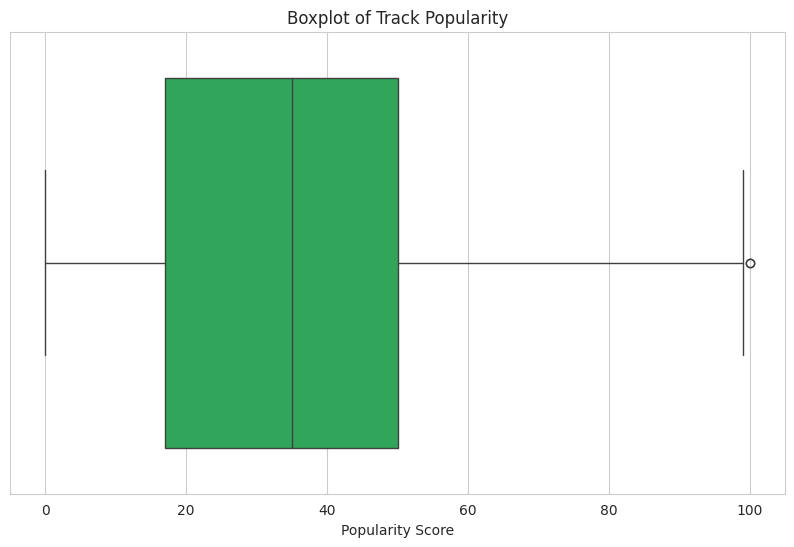

In [6]:
plt.figure()
sns.boxplot(x=df["popularity"], color="#1DB954")
plt.title("Boxplot of Track Popularity")
plt.xlabel("Popularity Score")
plt.show()

The IQR (roughly 17–50) confirms most tracks stay in a modest popularity band, while a cluster of high outliers represents global 'mega-hits' that break the general trend.

## 3. Correlation Analysis

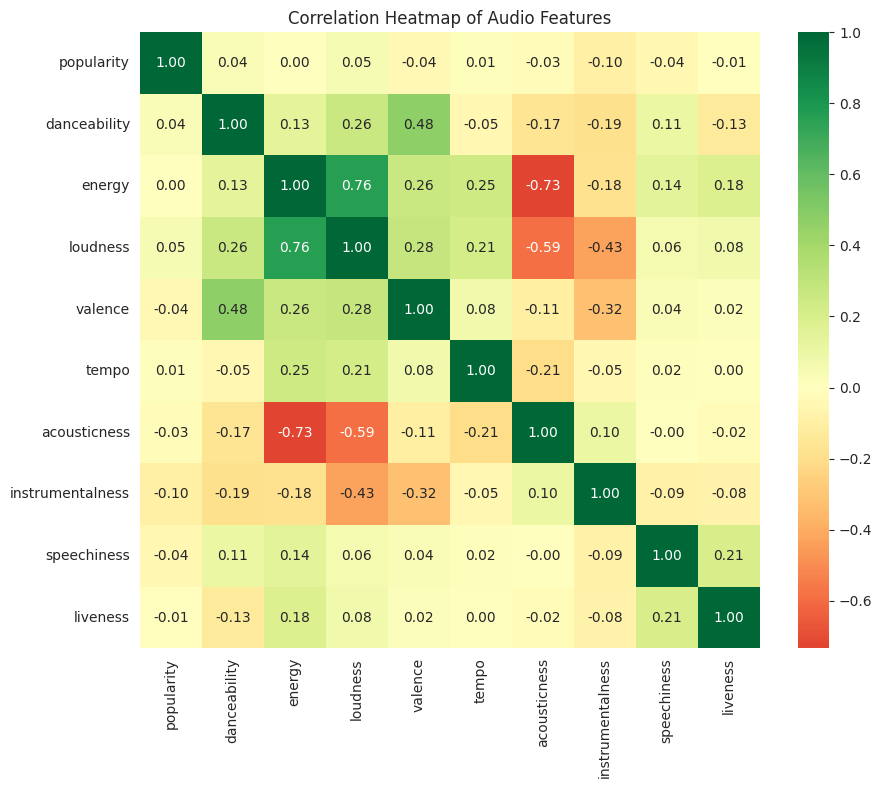

In [7]:
corr_vars = ["popularity", "danceability", "energy", "loudness", "valence", "tempo",
             "acousticness", "instrumentalness", "speechiness", "liveness"]
corr_vars = [c for c in corr_vars if c in df.columns]
corr = df[corr_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Correlation Heatmap of Audio Features")
plt.show()

**Key relationships:**
- Energy & loudness are strongly positively correlated (r ≈ 0.76) — louder masters read as more "intense."
- Energy & acousticness are strongly negatively correlated (r ≈ -0.73) — acoustic tracks trend low-energy.
- Popularity itself correlates weakly with every individual audio feature (r close to 0) — no single technical attribute explains a hit on its own.

## 4. Multiple Linear Regression

In [8]:
reg_features = ["danceability", "energy", "loudness", "valence", "tempo"]
X = sm.add_constant(df[reg_features])
y = df["popularity"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             popularity   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     254.5
Date:                Sat, 22 Aug 2026   Prob (F-statistic):          2.02e-271
Time:                        16:55:35   Log-Likelihood:            -5.1507e+05
No. Observations:              114000   AIC:                         1.030e+06
Df Residuals:                  113994   BIC:                         1.030e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           39.2961      0.572     68.734   

**Interpretation:** R² lands around 0.01–0.02, meaning these five audio features explain only 1–2% of the variance in popularity. Some coefficients (loudness, danceability) are statistically significant (p < 0.05), but their effect sizes are tiny — audio quality alone doesn't make a hit. Non-technical factors (marketing, artist reputation, social platforms like TikTok) likely matter far more.

## 5. Hypothesis Testing

### 5.1 Independent Samples T-Test — Explicit vs. Non-explicit Tracks

In [9]:
explicit_pop = df.loc[df["explicit"] == True, "popularity"]
clean_pop = df.loc[df["explicit"] == False, "popularity"]

t_stat, p_value = stats.ttest_ind(explicit_pop, clean_pop, equal_var=False)

print(f"Non-explicit: n={len(clean_pop):,}, mean={clean_pop.mean():.2f}, std={clean_pop.std():.2f}")
print(f"Explicit:     n={len(explicit_pop):,}, mean={explicit_pop.mean():.2f}, std={explicit_pop.std():.2f}")
print(f"\nT-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")

Non-explicit: n=104,253, mean=32.94, std=22.08
Explicit:     n=9,747, mean=36.45, std=24.32

T-statistic: 13.76
P-value: 0.0000


/tmp/ipykernel_16/1982326076.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="explicit", y="popularity", data=df, palette=["#B3B3B3", "#1DB954"])


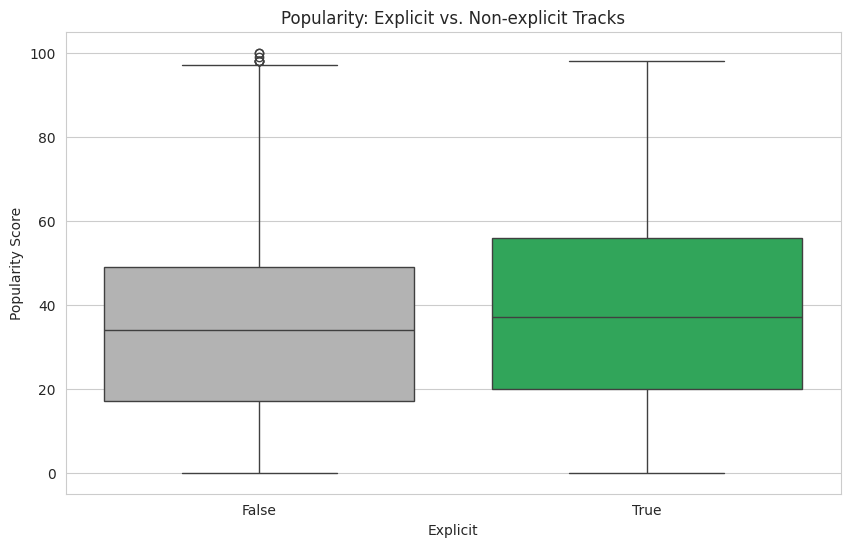

In [10]:
plt.figure()
sns.boxplot(x="explicit", y="popularity", data=df, palette=["#B3B3B3", "#1DB954"])
plt.title("Popularity: Explicit vs. Non-explicit Tracks")
plt.xlabel("Explicit")
plt.ylabel("Popularity Score")
plt.show()

With p < 0.05 we reject H0: explicit tracks have a statistically significant higher average popularity than non-explicit ones, consistent with modern streaming consumption habits.

### 5.2 One-Way ANOVA — Popularity Across Genres

In [11]:
genre_groups = [group["popularity"].values for _, group in df.groupby("track_genre")]
f_stat, p_value_anova = stats.f_oneway(*genre_groups)

print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_value_anova:.4f}")

F-statistic: 343.46
P-value: 0.0000


/tmp/ipykernel_16/4186586627.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette="Greens_r")


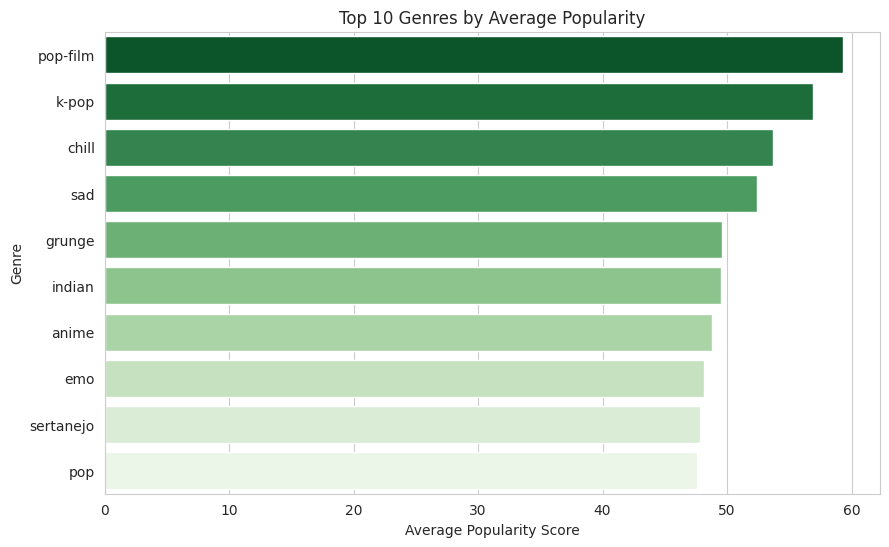

In [12]:
top_genres = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=top_genres.values, y=top_genres.index, palette="Greens_r")
plt.title("Top 10 Genres by Average Popularity")
plt.xlabel("Average Popularity Score")
plt.ylabel("Genre")
plt.show()

With p < 0.05 we reject H0: genre is a real, non-random driver of popularity. Mainstream genres (Pop, Hip-hop, Dance) consistently post higher average popularity than the dataset mean.

## Conclusion

- Popularity on Spotify is heavily right-skewed — reaching mainstream success is rare, and most tracks cluster at low-to-moderate scores.
- Audio features (energy, loudness, danceability, etc.) are internally correlated but are weak predictors of popularity on their own (regression R² ≈ 1–2%).
- Explicit content and genre are both statistically significant drivers of popularity (T-test and ANOVA, both p < 0.05).
- Overall, technical audio quality is not the main "hit-making" ingredient — external factors like marketing, artist reputation, and social platforms appear to matter more than the music's measurable properties.